In [1]:
from minigrad import *
from graphviz import Digraph

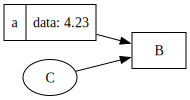

In [2]:
dot = Digraph(graph_attr={'rankdir': 'LR'})
dot.node('B', shape='record')
dot.node(name='A', label = '{a | data: 4.23}', shape='record')
dot.node('C')
dot.edge('A','B')
dot.edge('C','B')
dot

In [3]:
def trace(root : Value):
    nodes = set()
    edges = set()

    # use DFS, DAG so keep going till all edges explored.
    nodes.add(root)
    for child in root._prev:
        edges.add((child, root))
        n, e = trace(child)
        nodes.update(n)
        edges.update(e)

    return nodes, edges


def draw_dot(root):
    dot = Digraph(
        graph_attr={'rankdir':'LR'}
    )

    nodes, edges = trace(root)

    for n in nodes:
        dot.node(name=str(id(n)), label="{ %s | data: %.4f | grad: %.4f}" % (n.label, n.data, n.grad), shape='record')
        # if op node, create one
        if n._op != '':
            dot.node(name = str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for a, b in edges:
        dot.edge(str(id(a)), str(id(b)) + b._op)

    return dot

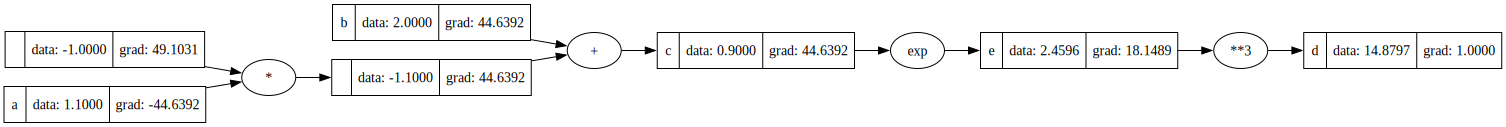

In [4]:
a = Value(1.1) ; a.label = 'a'
b = Value(2.0) ; b.label = 'b'
c = b - a ; c.label = 'c'
e = c.exp(); e.label = 'e'
d = e**3 ; d.label = 'd'

d.backward()
draw_dot(d)

In [5]:
# testing grads
h = 0.0000001

a = Value(1.1) + h; a.label = 'a'
b = Value(2.0) ; b.label = 'b'
c = b - a; c.label = 'c'
e = c.exp(); e.label = 'e'
d1 = e**3 ; d.label = 'd'
print((d1.data - d.data) / h)

-44.639188470085855


In [6]:
from nn import Neuron, MLP, Layer

In [7]:
x = [Value(1.0,label='d1'),Value(2.0,label='d2'),Value(3.0,label='d3')]
m = MLP(3, [4,4,1])
n = m(x)
n.backward()

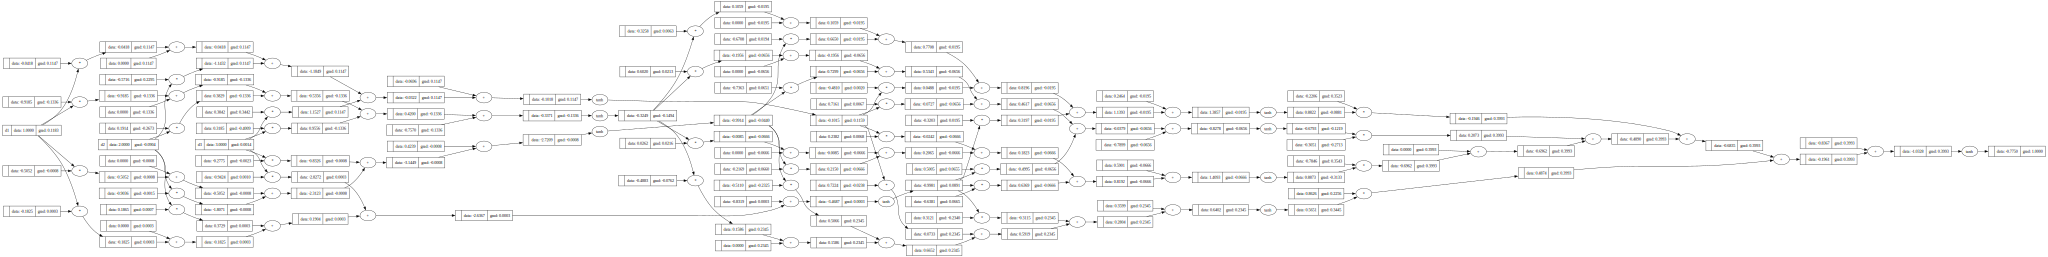

In [8]:
draw_dot(n)

In [9]:
 ## training
xs = [
    [0,0],
    [0,1],
    [1,1],
    [1,0]
]

ys = [1,1,1,1]

m = MLP(2, [2, 1])

In [10]:
y_preds = [m(x) for x in xs]
y_preds

[Value(data=-0.390743614137749),
 Value(data=-0.334078410884387),
 Value(data=-0.4180428180508996),
 Value(data=-0.4639462280586332)]

In [11]:
h = 0.01
loss_vals = []
params = m.parameters()
for epoch in range(10000):
    y_preds = [m(x) for x in xs]
    loss = sum((pred - true)**2 for pred, true in zip(y_preds, ys))
    loss_vals.append(loss.data)

    # remember to zero grad!
    for p in params:
        p.grad = 0

    loss.backward()
    for p in params:
        p.data -= p.grad * h

    if epoch % 1000 == 0:
        print(f'epoch {epoch}, loss={loss.data}')

print(loss)
print(y_preds)

epoch 0, loss=7.867916999125576
epoch 1000, loss=0.002756644183776996
epoch 2000, loss=0.0013261957591222252
epoch 3000, loss=0.0008675778767703908
epoch 4000, loss=0.0006428667575550509
epoch 5000, loss=0.0005098327480761541
epoch 6000, loss=0.0004220122275628433
epoch 7000, loss=0.000359764727253123
epoch 8000, loss=0.0003133714543262133
epoch 9000, loss=0.00027747757283848995
Value(data=0.0002489177602545171)
[Value(data=0.9899157469772969), Value(data=0.9917674379513083), Value(data=0.994555499455526), Value(data=0.9929425261485229)]


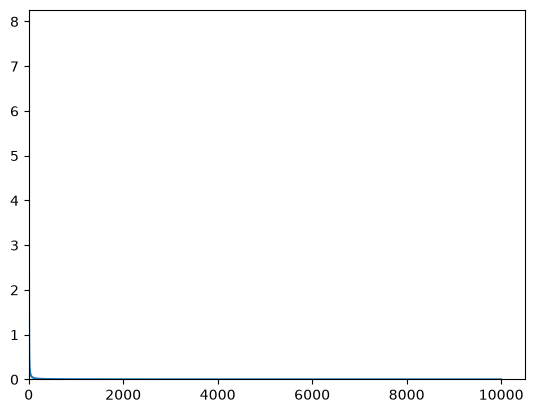

In [12]:
from matplotlib import pyplot as plt
plt.plot(loss_vals)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show()

In [13]:
for p in params:
    print(f"Val: {p.data}, Grad: {p.grad}")

Val: -0.04450135644090575, Grad: 0.0001364660651688359
Val: -0.3787677605206445, Grad: 0.0001158659867892724
Val: -0.8767650028928623, Grad: 0.0004427043595736701
Val: -0.6641979872512903, Grad: 4.265274292029482e-05
Val: 0.13347409330752527, Grad: 0.0001465805843449672
Val: -1.0428856317084145, Grad: 0.00032794916938259645
Val: -1.098890351690497, Grad: 0.0007608091537960808
Val: -0.9878825127572733, Grad: 0.0008042859489331817
Val: 1.0983839158362594, Grad: -0.000991478322444443
